# Persian Digits Hand Writing Image Classification **Fully Connected Neural Network**

## 1.Import Libraries

In [31]:
import cv2
import numpy as np
from scipy import io
from tensorflow import keras
import matplotlib.pyplot as plt
from keras.models import Sequential
from sklearn.model_selection import train_test_split
from keras.losses import SparseCategoricalCrossentropy
from keras.layers import Dense, Dropout, Softmax, Flatten


## 2. Persian Handwritten Digits Dataset

A dataset containing handwritten Persian digit images (`۰` to `۹`) used to train and evaluate the neural network classification model.


In [2]:
digits = io.loadmat('Data_hoda_full.mat')

## 3. Data Inspection

Inspect the dataset structure by checking its available keys and shapes.


In [3]:
digits.keys()

dict_keys(['__header__', '__version__', '__globals__', 'Data', 'labels'])

In [6]:
print(f'Data Shape: {digits['Data'].shape}\nLabels Shape: {digits['labels'].shape}')

Data Shape: (60000, 1)
Labels Shape: (60000, 1)


## 4. Data Reshaping

Remove unnecessary singleton dimensions from the data and labels using np.squeeze().

In [8]:
digits['Data'] = np.squeeze(digits['Data'])
digits['labels'] = np.squeeze(digits['labels'])
print(f'Data Shape: {digits['Data'].shape}\nLabels Shape: {digits['labels'].shape}')

Data Shape: (60000,)
Labels Shape: (60000,)


## 5. Visualize Sample Image

Display a sample handwritten digit from the dataset along with its corresponding label.

Enter the number of image sample: 40


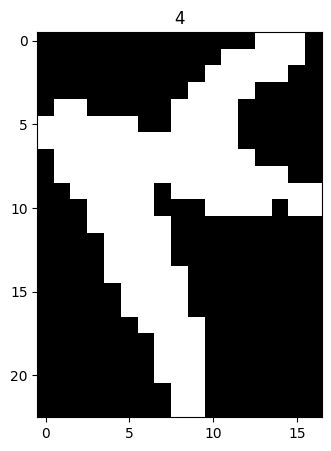

In [10]:
i = int(input('Enter the number of image sample: '))
plt.figure(figsize= (5, 5))
plt.imshow(digits['Data'][i], cmap= 'gray')
plt.title(digits['labels'][i]);

## 6.Image Preprocessing

The original images have different dimensions, so all images are resized to **8 × 8** pixels and normalized to the range `[0, 1]`.

After preprocessing:

```python
(60000, 8, 8)
```

All **60,000 images** now have a consistent shape suitable for model training.


In [14]:
print(f'Sample 1: {digits['Data'][30].shape}\nSample 2: {digits['Data'][100].shape}\nSmaple 3: {digits['Data'][450].shape}')

Sample 1: (18, 17)
Sample 2: (54, 11)
Smaple 3: (20, 32)


In [26]:
digits['Data'] = np.array([cv2.resize(img, (8, 8)) / 255 for img in digits['Data']])
print(f'{digits['Data'].shape}')

(60000, 8, 8)


## 7.Train-Test Split

The dataset is split into **80% training** and **20% testing** data using `train_test_split`.


In [30]:
X_train, X_test, y_train, y_test = train_test_split(digits['Data'], digits['labels'], test_size= 0.2, random_state= 42)
print(f'X_train shape: {X_train.shape}\nX_test shape: {X_test.shape}\ny_train shape: {y_train.shape}\ny_test shape: {y_test.shape}')

X_train shape: (48000, 8, 8)
X_test shape: (12000, 8, 8)
y_train shape: (48000,)
y_test shape: (12000,)
